# A1-1 쇼핑몰 고객 분석과 RFM 세분화

이 노트북은 공개 거래 데이터를 불러와 결측치와 이상치를 처리하고, 숫자·텍스트·이미지 배열 특징을 만든 뒤 RFM으로 고객을 네 그룹으로 분류한다. 모든 결과는 `src/pipeline.py`의 재사용 가능한 `DataAnalyzer`를 통해 계산한다.

## 1. 데이터 출처와 분석 설계

- 출처: UCI Machine Learning Repository, **Online Retail**
- DOI: <https://doi.org/10.24432/C5BW33>
- 라이선스: CC BY 4.0
- 원본: 541,909행, 8개 원본 필드, 2010-12-01~2011-12-09
- 분석 표본: seed 42로 재현 가능하게 추출한 25,000행, 14개 열

`product_image`는 실제 상품 사진이라고 주장하지 않는다. `stock_code`에서 결정론적으로 만든 8×8 교육용 배열이며, CSV 문자열을 `np.fromstring`으로 읽어 배열 평균과 표준편차를 반복문 없이 계산한다. RFM 기준일은 마지막 유효 구매일 다음 날이다.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import json
import numpy as np
import pandas as pd

from src.pipeline import DataAnalyzer

# 경로를 상수로 모아 모든 셀이 같은 데이터와 산출물 위치를 사용하게 한다.
pd.set_option("display.max_columns", 30)
DATA_PATH = Path("data/online_retail_sample.csv")
FIGURES = Path("figures")
OUTPUTS = Path("outputs")

## 2. 데이터 로드와 기본 탐색

In [2]:
analyzer = DataAnalyzer(DATA_PATH, outlier_threshold=1.5)
# 로드 단계에서 최소 행·열 수, 필수 열, 날짜와 이미지 배열 형식을 검증한다.
df = analyzer.load_data()
print(f"shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.drop(columns="product_image").head())
df.info()

shape: 25,000 rows × 14 columns


,row_id,source_row_id,invoice_no,stock_code,description,quantity,order_date,unit_price,customer_id,country,amount,image_height,image_width
0,0,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,8
1,1,31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,8,8
2,2,53,536373,37370,RETRO COFFEE MUGS ASSORTED,6,2010-12-01 09:02:00,1.06,17850.0,United Kingdom,6.36,8,8
3,3,112,536381,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,24,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,30.00,8,8
4,4,123,536381,22083,PAPER CHAIN KIT RETROSPOT,1,2010-12-01 09:41:00,2.95,15311.0,United Kingdom,2.95,8,8


<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         25000 non-null  int64         
 1   source_row_id  25000 non-null  int64         
 2   invoice_no     25000 non-null  str           
 3   stock_code     25000 non-null  str           
 4   description    24935 non-null  str           
 5   quantity       25000 non-null  int64         
 6   order_date     25000 non-null  datetime64[us]
 7   unit_price     25000 non-null  float64       
 8   customer_id    18700 non-null  float64       
 9   country        25000 non-null  str           
 10  amount         25000 non-null  float64       
 11  product_image  25000 non-null  object        
 12  image_height   25000 non-null  int64         
 13  image_width    25000 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(5), object(1), str(4)
memory usage: 2.7+ 

In [3]:
overview = analyzer.overview()
# 타입별 열 수와 수치형 기술 통계를 함께 확인해 데이터 구조를 증명한다.
display(pd.Series(overview["missing_by_column"], name="missing_count").to_frame())
display(
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .rename("column_count")
    .to_frame()
)
display(df.select_dtypes(include="number").describe().T)

,missing_count
row_id,0
source_row_id,0
invoice_no,0
stock_code,0
description,65
quantity,0
order_date,0
unit_price,0
customer_id,6300
country,0


,column_count
dtype,
int64,5
str,4
float64,3
datetime64[us],1
object,1


,count,mean,std,min,25%,50%,75%,max
row_id,25000.0,12499.500000,7217.022701,0.0,6249.75,12499.50,18749.25,24999.00
source_row_id,25000.0,271052.645280,156655.821988,2.0,135444.00,270820.50,406505.50,541898.00
quantity,25000.0,9.505600,43.222214,-2376.0,1.00,3.00,10.00,2880.00
unit_price,25000.0,5.111353,120.066142,0.0,1.25,2.08,4.13,13541.33
customer_id,18700.0,15257.567166,1713.557230,12347.0,13899.75,15078.00,16764.00,18287.00
amount,25000.0,17.487655,131.268746,-11586.5,3.38,9.75,17.40,13541.33
image_height,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00
image_width,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00


### 주요 수치형 변수의 기술 통계 해석

- `quantity`는 평균 **9.51**, 중앙값 **3**, 표준편차 **43.22**, Q1 **1**, Q3 **10**이다. 평균이 중앙값보다 크고 표준편차가 큰 점은 소수의 대량 주문과 음수 반품 때문에 분포가 비대칭임을 보여준다. 따라서 일반적인 주문 수량은 평균보다 중앙값과 사분위 범위로 설명하는 편이 안전하다.
- `unit_price`는 평균 **£5.11**, 중앙값 **£2.08**, 표준편차 **£120.07**, Q1 **£1.25**, Q3 **£4.13**이다. 중앙 50%는 비교적 좁지만 표준편차가 매우 크므로 일부 고가 품목이나 조정 거래가 전체 변동성을 크게 높인다.
- `amount`는 평균 **£17.49**, 중앙값 **£9.75**, 표준편차 **£131.27**, Q1 **£3.38**, Q3 **£17.40**이다. 평균이 중앙값의 약 1.8배이고 표준편차도 크므로 오른쪽 꼬리가 긴 거래금액 분포임을 확인할 수 있다. 이 결과는 평균·표준편차만으로 이상치를 정하기보다 IQR을 사용하고 처리 전후를 함께 비교해야 한다는 근거가 된다.

위 수치는 표본의 기술 통계이며, 반품과 취소를 포함한 원본 거래 기준이다. 고객 세분화용 Monetary에서는 뒤에서 유효 양수 구매와 IQR 조정 금액을 별도로 사용한다.

### 탐색 해석

수치형, 문자열형, 날짜형, NumPy 배열형이 함께 존재한다. 실제 표본에서 `description` 65건과 `customer_id` 6,300건의 결측을 확인했다. 고객 ID는 식별자이므로 평균이나 임의 값으로 채우면 서로 다른 고객을 합치는 오류가 생긴다. 따라서 설명은 상품 그룹의 최빈값으로 보완하고, 고객 ID 결측은 보존했다가 RFM 집계에서만 제외한다.

## 3. 결측치 처리와 멀티모달 특징 공학

In [4]:
missing_report = analyzer.handle_missing(strategy="group_mode", group_col="stock_code")
display(pd.DataFrame(missing_report))

# 금액, 단어 수, 이미지 평균·표준편차를 반복문 없이 벡터화해 생성한다.
df = analyzer.engineer_features()
display(df[["quantity", "unit_price", "amount", "description", "word_count", "image_mean", "image_std"]].head())

,before,after
row_id,0,0
source_row_id,0,0
invoice_no,0,0
stock_code,0,0
description,65,0
quantity,0,0
order_date,0,0
unit_price,0,0
customer_id,6300,6300
country,0,0


,quantity,unit_price,amount,description,word_count,image_mean,image_std
0,8,2.75,22.00,CREAM CUPID HEARTS COAT HANGER,5,127.0,73.891815
1,48,0.85,40.80,INFLATABLE POLITICAL GLOBE,3,127.5,72.368843
2,6,1.06,6.36,RETRO COFFEE MUGS ASSORTED,4,129.0,73.864738
3,24,1.25,30.00,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,5,128.5,74.318573
4,1,2.95,2.95,PAPER CHAIN KIT RETROSPOT,4,126.0,72.090218


- 숫자: `amount = quantity × unit_price`를 NumPy 벡터 연산으로 계산했다.
- 텍스트: 상품 설명을 공백 단위로 나눈 `word_count`를 생성했다.
- 이미지 배열: 25,000×64 행렬로 쌓아 행 방향 `mean`과 `std`를 한 번에 계산했다.

텍스트 결측은 그룹 대치 후에도 값이 없으면 `UNKNOWN PRODUCT`로 표시하고, 이미지 배열은 길이가 다르거나 비어 있거나 NaN/무한대를 포함하면 통계를 만들지 않고 명시적으로 실패시킨다. 이 정책은 품질 문제를 0으로 조용히 대치해 숨기지 않는다.

`to_numpy()`와 `np.stack()`은 동종 값을 연속적인 배열로 배치하여 Python 객체 순회 비용을 줄이고, NumPy의 컴파일된 루프와 SIMD 친화적 연산을 사용하기 위한 선택이다. 다만 전체 이미지 행렬을 한 번에 적재하므로 원본 전체 규모에서는 배치 처리나 메모리 매핑이 필요하다.

## 4. IQR 이상치 탐지와 처리

\[
IQR = Q_3 - Q_1, \quad
Lower = Q_1 - 1.5IQR, \quad
Upper = Q_3 + 1.5IQR
\]

IQR은 평균·표준편차처럼 정규분포를 가정하지 않고 중앙 50%에 기반하므로 오른쪽 꼬리가 긴 거래금액에 비교적 견고하다. 하지만 비대칭 분포의 정상적인 고액 주문도 이상치로 과다 표시할 수 있다. 반품과 취소는 음수라는 비즈니스 의미가 있으므로 별도로 보존하고, 양수 구매 금액의 극단값만 상한·하한으로 클리핑했다. 원본 `amount`도 남겨 처리 전후를 검증할 수 있게 했다.

column                                                      amount
method                                                        clip
output_column                                         amount_clean
before_count                                                  1925
after_count                                                      0
bounds           {'q1': 3.75, 'q3': 17.700000000000003, 'iqr': ...
dtype: object

IQR positive-purchase outliers: 1,925


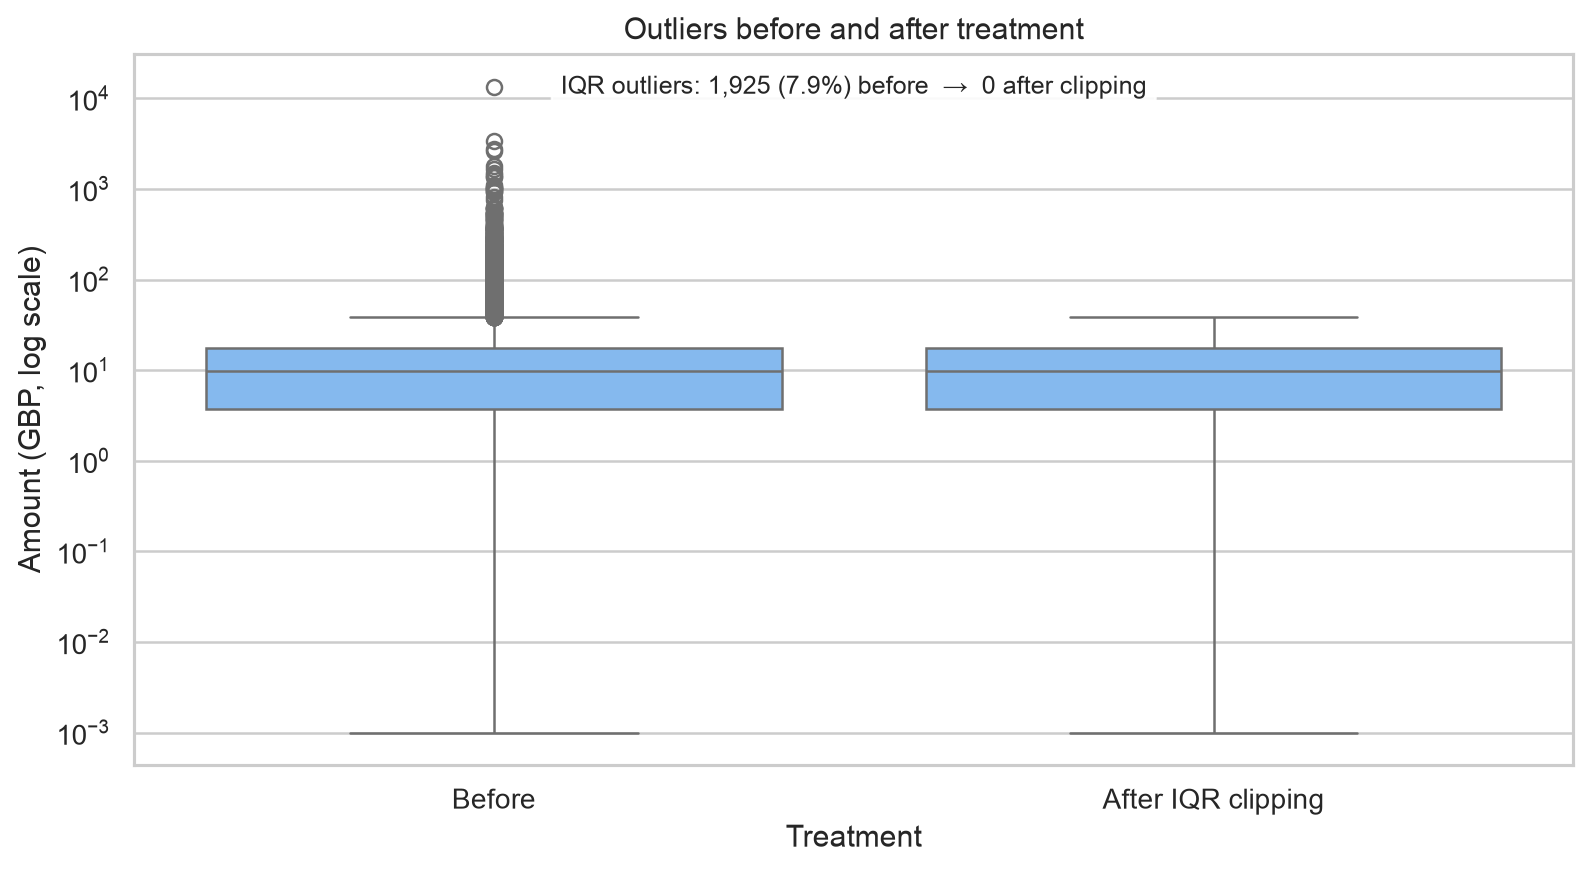

In [5]:
outliers_before = analyzer.detect_outliers("amount", positive_only=True)
# 원본 amount는 보존하고 양수 구매의 IQR 극단값만 amount_clean에 클리핑한다.
outlier_report = analyzer.treat_outliers(
    "amount", method="clip", output_col="amount_clean", positive_only=True
)
display(pd.Series(outlier_report))
print(f"IQR positive-purchase outliers: {len(outliers_before):,}")
display(Image(filename=str(FIGURES / "02_outlier_boxplot.png")))

## 5. 여섯 종류 이상의 시각화

,file,chart_type,title,x_axis,y_axis
0,01_amount_histogram.png,Histogram,Purchase amount distribution (up to 99th perce...,Amount (GBP),Count
1,02_outlier_boxplot.png,Box plot,Outliers before and after treatment,Treatment,"Amount (GBP, log scale)"
2,03_segment_bar.png,Bar chart,Customers by RFM segment,Segment,Customers
3,04_rfm_heatmap.png,Heatmap,RFM correlation heatmap,RFM metrics,RFM metrics
4,05_rfm_scatter.png,Scatter plot,Frequency vs monetary value by segment,Frequency (orders),Monetary (GBP)
5,06_monthly_sales_line.png,Line chart,Monthly sales trend,Month,IQR-adjusted sales (GBP)


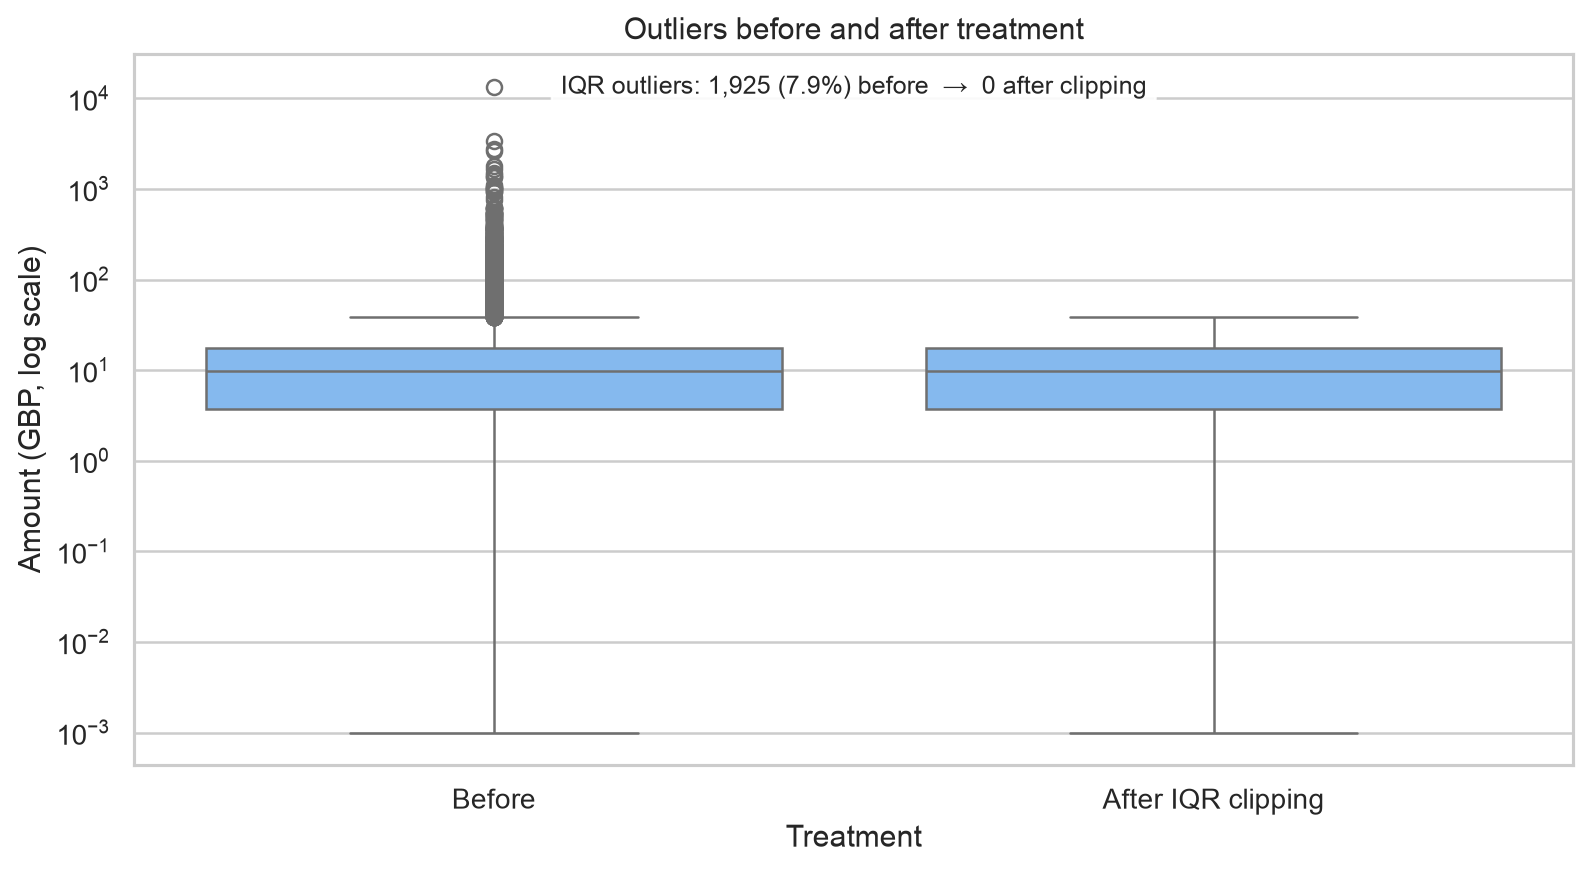

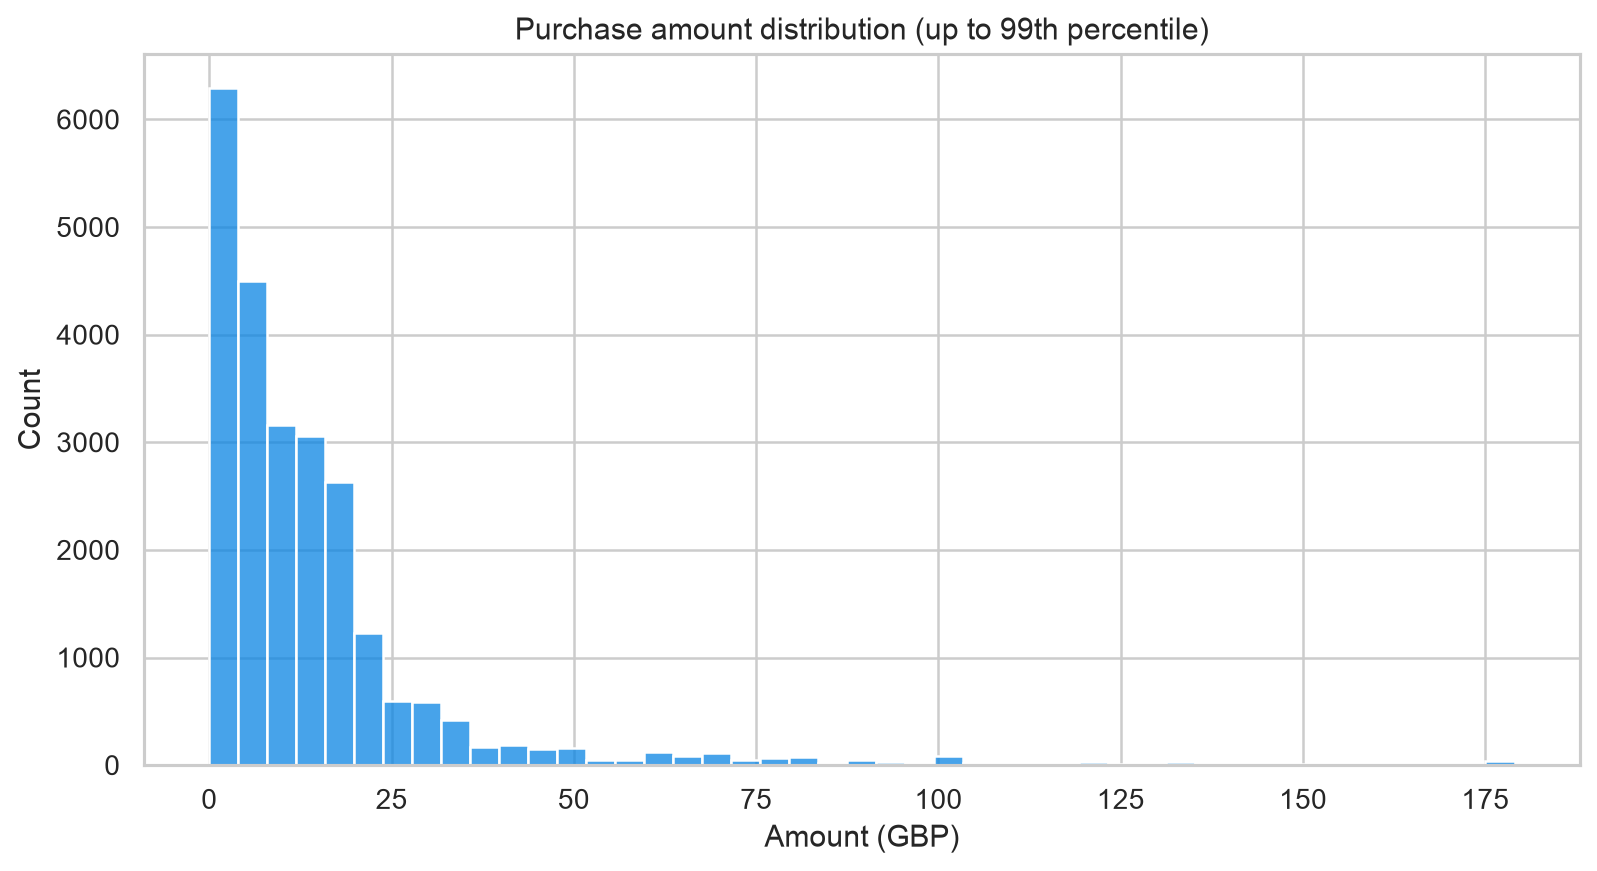

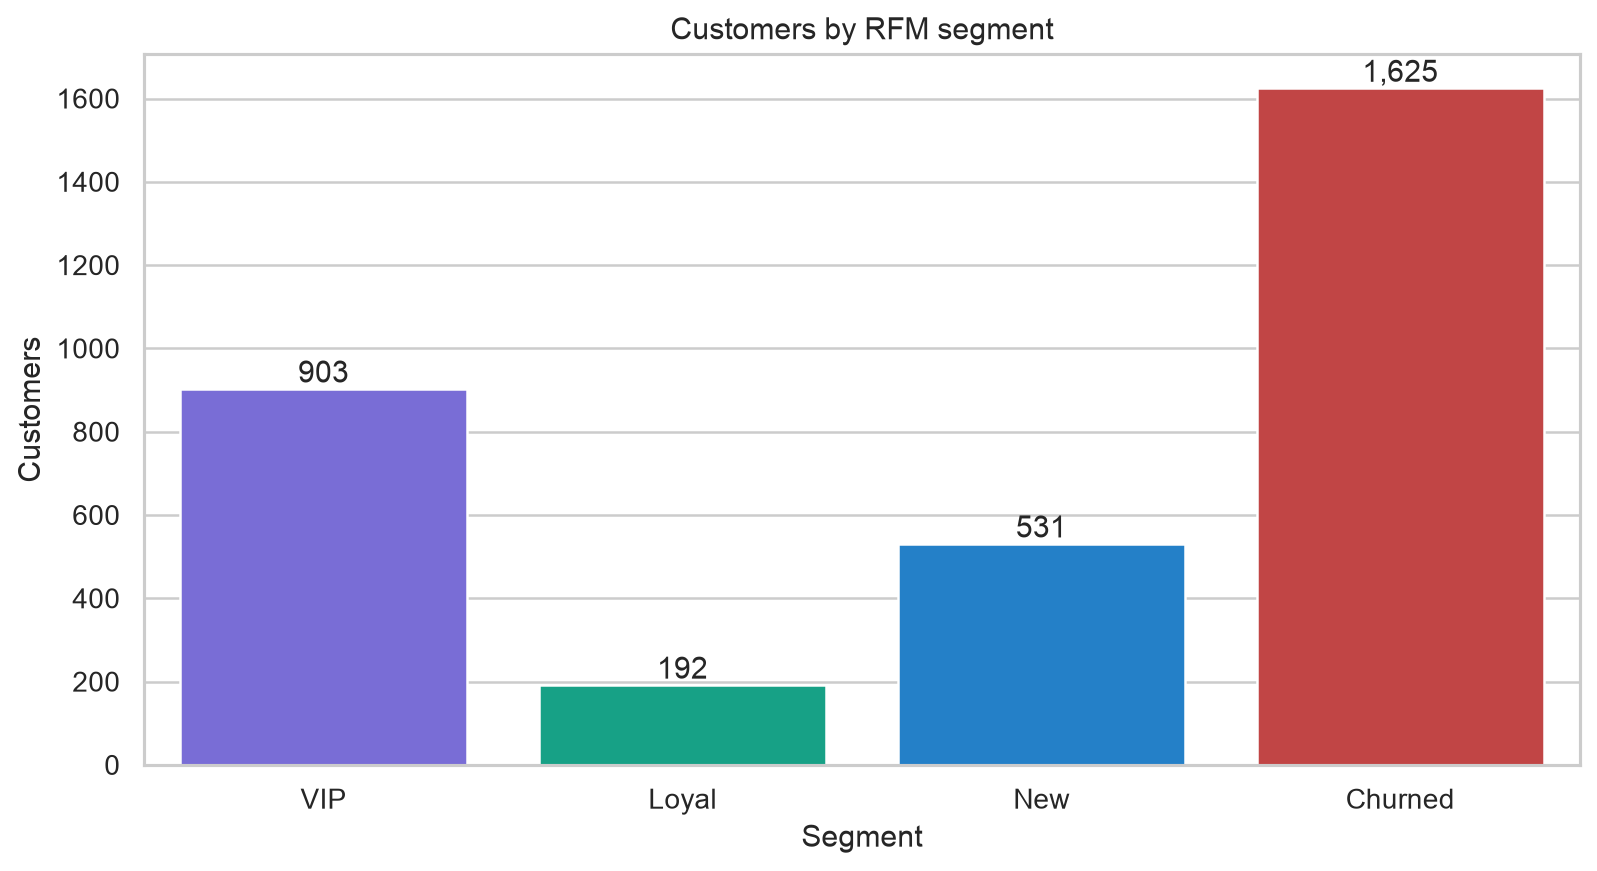

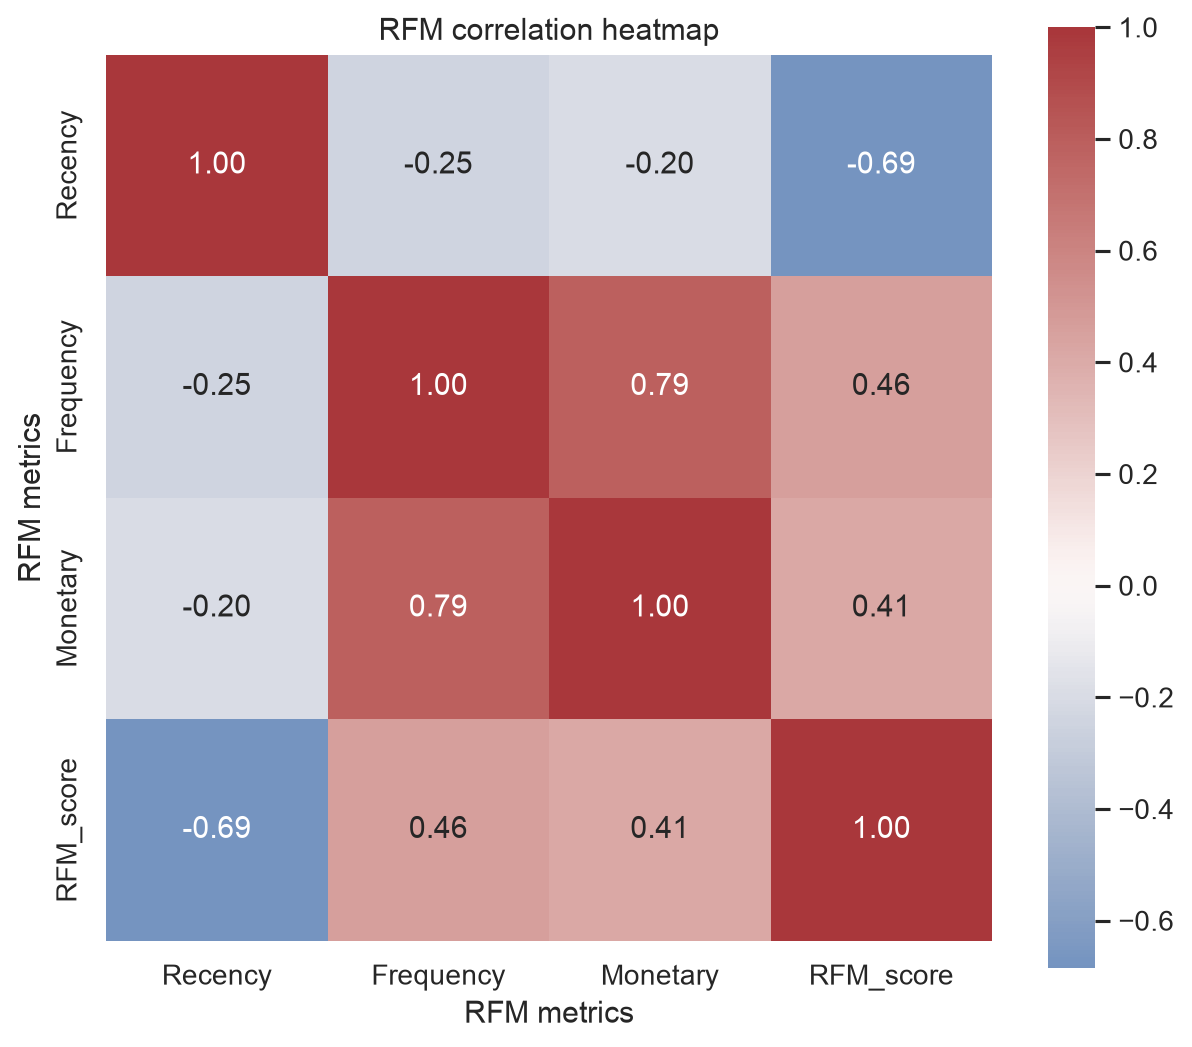

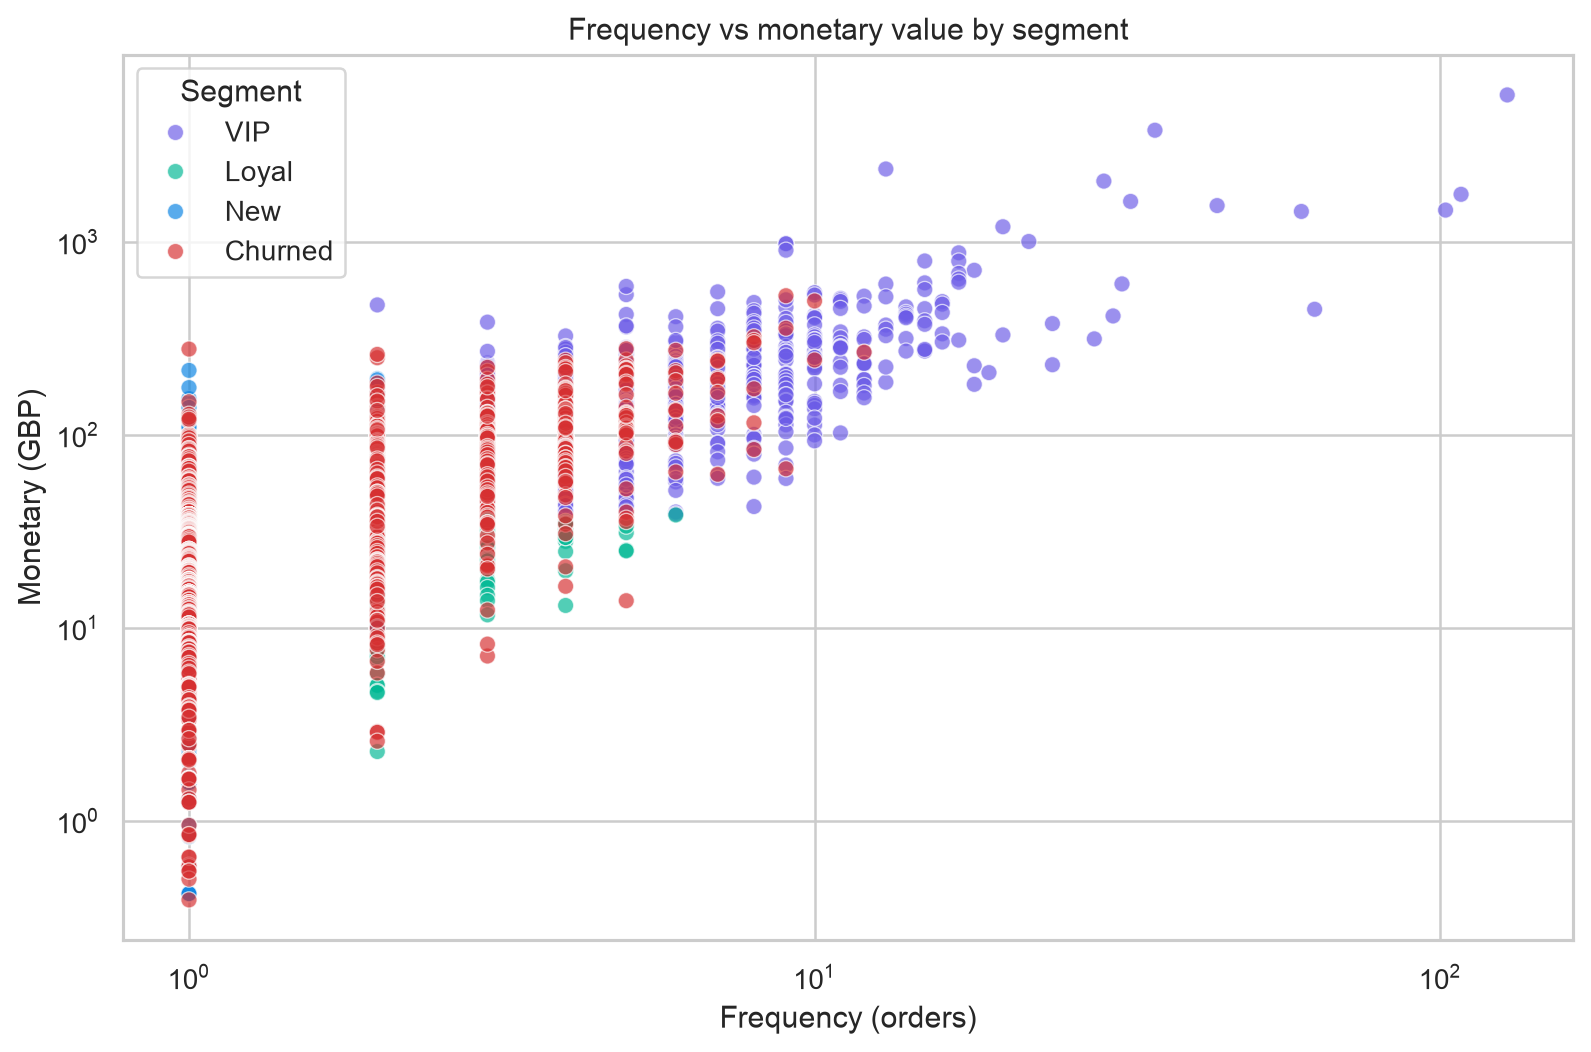

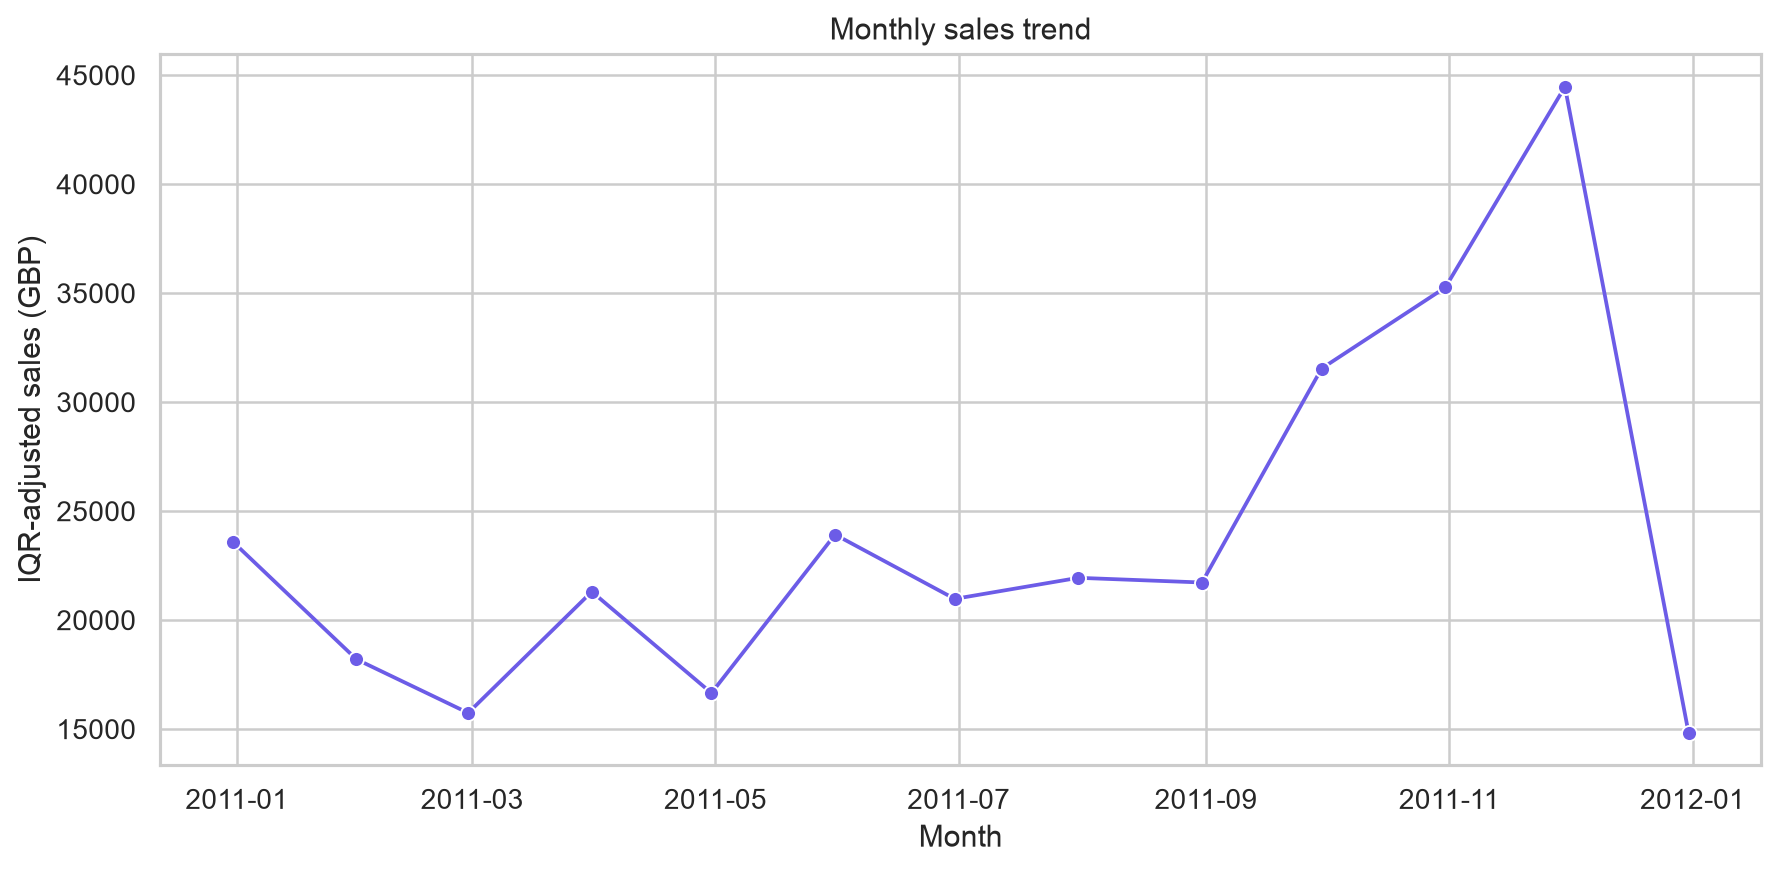

In [6]:
# 제목과 x/y축 레이블 증거를 표로 먼저 제시한 뒤 실제 PNG를 표시한다.
visualization_evidence = pd.read_csv(OUTPUTS / "visualization_evidence.csv")
display(visualization_evidence)

# 서로 다른 분석 목적을 가진 정적 그래프를 순서대로 노트북에 표시한다.
for filename in [
    "02_outlier_boxplot.png",
    "01_amount_histogram.png",
    "03_segment_bar.png",
    "04_rfm_heatmap.png",
    "05_rfm_scatter.png",
    "06_monthly_sales_line.png",
]:
    display(Image(filename=str(FIGURES / filename)))

히스토그램은 구매금액의 강한 오른쪽 꼬리를 보여준다. 상관 히트맵에서 Frequency와 Monetary의 상관은 약 0.79로 높지만, 상관관계가 구매 횟수 증가의 인과 효과를 증명하지는 않는다. 월별 추세는 2011년 가을의 상승과 11월 고점을 보여주며, 마지막 12월은 9일까지만 포함된 불완전 월이므로 전월과 직접 비교하면 안 된다.

## 6. RFM 고객 세분화

- Recency: 기준일에서 마지막 구매일까지의 일수(작을수록 좋음)
- Frequency: 서로 다른 주문서 수(클수록 좋음)
- Monetary: IQR 조정된 유효 구매 금액 합계(클수록 좋음)

각 지표를 사분위 점수 1~4로 바꾸고 `VIP`, `Loyal`, `New`, `Churned`로 분류한다. 사분위는 사전 비즈니스 임계값이 없는 탐색 단계에서 각 점수 구간에 관측치를 충분히 확보하면서 네 운영 그룹과 연결하기 쉬워 선택했다. 3분위는 경계가 거칠어 그룹이 커지고, 5분위는 경계 근처 고객 이동과 작은 그룹을 늘릴 수 있다. 운영 전에는 30/90/180일 같은 실제 캠페인·구매주기 임계값과 비교해야 한다. 기준일은 데이터의 마지막 유효 구매일 다음 날인 2011-12-10이다.

In [7]:
# 마지막 유효 구매일 다음 날을 기준으로 RFM을 계산하고 네 세그먼트로 분류한다.
rfm = analyzer.calculate_rfm(amount_col="amount_clean")
segment_summary = analyzer.segment_summary()
display(rfm.head(10))
display(segment_summary.style.format({
    "mean_recency": "{:.1f}",
    "mean_frequency": "{:.1f}",
    "mean_monetary": "£{:,.0f}",
    "total_monetary": "£{:,.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
}))

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
customer_id,,,,,,,,
14911,1,128,5786.890,4,4,4,12,VIP
14646,1,35,3797.240,4,4,4,12,VIP
14096,4,13,2390.960,4,4,4,12,VIP
14298,8,29,2069.470,4,4,4,12,VIP
17841,1,108,1767.990,4,4,4,12,VIP
14156,23,32,1624.200,4,4,4,12,VIP
13089,4,44,1545.370,4,4,4,12,VIP
12748,1,102,1464.495,4,4,4,12,VIP
15311,0,60,1441.020,4,4,4,12,VIP


,customers,mean_recency,median_frequency,mean_frequency,mean_monetary,total_monetary,customer_share,revenue_share
Segment,,,,,,,,
VIP,903,21.2,4.000000,6.0,£180,"£162,839",27.8%,63.4%
Churned,1625,179.5,1.000000,1.7,£45,"£73,917",50.0%,28.8%
New,531,31.2,1.000000,1.1,£29,"£15,369",16.3%,6.0%
Loyal,192,27.6,2.000000,2.5,£25,"£4,795",5.9%,1.9%


Recency                               Frequency                   \
          count        mean median        std     count      mean median   
Segment                                                                    
Churned    1625  179.481846  162.0  92.356218      1625  1.701538    1.0   
Loyal       192   27.609375   26.0  17.053612       192  2.494792    2.0   
New         531   31.224105   30.0  17.837756       531  1.126177    1.0   
VIP         903   21.205980   18.0  16.510820       903  5.975637    4.0   

                  Monetary                                   
              std    count        mean   median         std  
Segment                                                      
Churned  1.253136     1625   45.487538   32.300   47.986590  
Loyal    0.772549      192   24.975000   26.060    9.002231  
New      0.332362      531   28.943145   19.900   28.972544  
VIP      7.974423      903  180.330854  115.425  296.749308

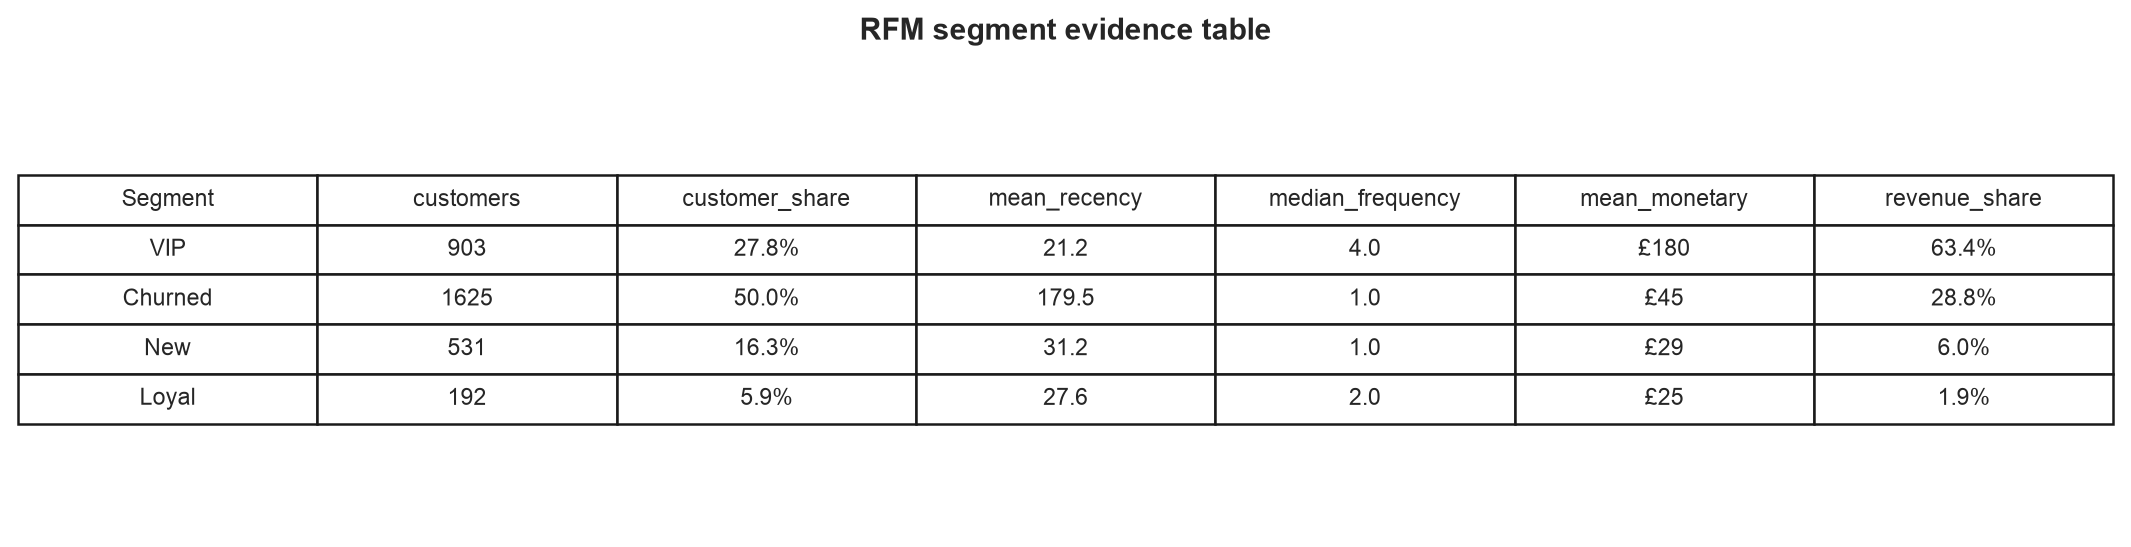

In [8]:
# 세그먼트별 count/mean/median/std를 계산해 해석의 수치 근거를 남긴다.
group_statistics = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].agg(
    ["count", "mean", "median", "std"]
)
display(group_statistics)
display(Image(filename=str(FIGURES / "07_segment_summary_table.png")))

## 7. 데이터 근거 기반 비즈니스 제안

1. **VIP 유지** — **(근거)** VIP는 고객의 27.8%지만 조정 매출의 63.4%를 만든다. **(실행)** 등급별 선공개와 서비스 혜택을 제공한다. 기대효과는 핵심 매출과 반복구매율 방어다. **(검증)** 대조군보다 90일 반복구매율·이탈률이 개선되지 않거나 증분 공헌이익이 0 이하면 가설을 지지하지 않는다.
2. **Churned 재활성화** — **(근거)** 고객의 50.0%가 Churned이며 평균 Recency는 179.5일이다. **(실행)** 기간 제한 인센티브를 무작위 대조 실험으로 운영한다. 기대효과는 전체 할인 없이 휴면 고객을 회수하는 것이다. **(검증)** 홀드아웃 대비 재활성화율·증분 공헌이익이 개선되지 않으면 가설을 지지하지 않으며, 이탈 사유 데이터가 추가로 필요하다.
3. **New의 두 번째 구매 유도** — **(근거)** New는 531명(16.3%)이고 구매빈도 중앙값은 1회다. **(실행)** 첫 구매 후 14일 내 사용 가이드와 연관상품 추천을 보낸다. 기대효과는 1회 구매자의 2회차 전환이다. **(검증)** 14/30일 2회차 구매율이 대조군보다 높지 않거나 반품 증가가 효과를 상쇄하면 가설을 지지하지 않는다.

이 제안들은 관찰 데이터에서 나온 가설이다. 캠페인의 인과 효과를 주장하려면 대조군과 비용·마진 데이터가 추가로 필요하다.

## 8. 한계와 재현성

- 25,000행 표본이므로 전체 541,909행의 정확한 모집단 추정치가 아니다.
- 거래 고객 ID 결측은 RFM에서 제외되어 비식별 구매를 대표하지 못한다.
- `product_image`는 배열 연습용 파생 데이터이며 시각적 상품 특성을 뜻하지 않는다.
- 반품/취소는 RFM 구매 집계에서 제외했지만 별도의 반품 행동 분석이 필요하다.
- 2011년 12월은 부분 월이다.

모든 표본 추출, 특징 생성, 경계값, 기준일은 코드에 명시되어 있다. `python -m scripts.run_analysis`로 산출물을 다시 만들 수 있다.

## 9. 다음 단계: 예측 모델 확장

권장 타깃은 기준일 이후 90일 동안 구매가 없으면 `churn_90d=1`인 이진 레이블이다. 기준일 이전 관측창에서 `Recency`, `Frequency`, `Monetary`, 평균 주문금액, 반품률, 구매 상품 수, 활동 개월 수, 국가, 최근 30/60/90일 구매 횟수와 금액을 피처로 사용할 수 있다. 미래 주문, 사후 RFM 세그먼트, 타깃 기간의 구매금액은 데이터 누수이므로 제외한다. 시간순 train/validation/test 분할과 Recall·PR-AUC·캘리브레이션을 함께 평가한다.